<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 1 — Procesamiento y Visualización de Datos Biomédicos</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporciona el dataset **Heart Failure Prediction** (Kaggle, fedesoriano, 2021), que contiene registros clínicos de **918 pacientes** con variables demográficas, de laboratorio y de electrocardiograma. La variable objetivo es `HeartDisease` (0 = sin enfermedad, 1 = con enfermedad).

Tu misión como analista: **explorar, limpiar, preprocesar y construir la matriz X e y** lista para ingresar a un modelo de ML clásico, aplicando todos los conceptos vistos en Clase 2.

---
> **Dataset:** `heart.csv`  
> **Fuente:** fedesoriano. (2021). *Heart Failure Prediction Dataset*. Kaggle. https://www.kaggle.com/fedesoriano/heart-failure-prediction

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

---## Ejercicio 1 — Diseño del pipeline (conceptual)

> **Antes de escribir una línea de código**, debes entender qué vas a hacer y por qué.

### 1.1 — Diagrama de bloques del pipeline

Completa el siguiente diagrama describiendo qué ocurre en cada etapa:

```
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│                 │     │                 │     │                 │
│   heart.csv     │────▶│ Separar X e y   │────▶│  Imputación     │
│   (raw data)    │     │                 │     │                 │
│                 │     │  ¿Qué haces?:   │     │  ¿Qué haces?:   │
│  N=918, d=11    │     │ Aislar Target   │     │ Tratar Nulos    │
└─────────────────┘     └─────────────────┘     └────────┬────────┘
                                                          │
                                                          ▼
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│                 │     │                 │     │                 │
│  X ∈ ℝ^(N×15)   │◀────│ Escalado (Z)    │◀────│ Codificación    │
│  y ∈ {0,1}^N    │     │                 │     │                 │
│                 │     │  ¿Qué haces?:   │     │  ¿Qué haces?:   │
│  listo p/ ML    │     │ Normalización   │     │ One-Hot Categor.│
└─────────────────┘     └─────────────────┘     └─────────────────┘
```

**📝 Tu respuesta (edita esta celda):**
- **???:** Separación de Features y Target (X, y)
- **???:** Imputación de valores faltantes (Mediana)
- **???** Codificación One-Hot para variables categóricas
- **???:** Escalado de datos mediante Z-score (StandardScaler)

### 1.2 — Representación matemática del pipeline

Completa las dimensiones y operaciones matemáticas para este dataset:

**Punto de partida — el dataset crudo:**

$$\text{heart.csv} \rightarrow \text{DataFrame} \in \mathbb{R}^{918 \times 12}$$

donde $N = $ 918 pacientes y $d+1 = $ 12 columnas (features + target).

---

**Paso 1 — Separar features y target:**

$$\text{DataFrame} \xrightarrow{\text{split}} X_{\text{raw}} \in \mathbb{R}^{918 \times \, \underline{11}}, \quad y \in \{0,1\}^{\underline{918}}$$

---

**Paso 2 — Codificación de variables categóricas (One-Hot):**

El dataset tiene columnas categóricas: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.

¿Cuántas columnas nuevas generan? Completa:
(hint: drop_first)
| Variable | Categorías | Columnas One-Hot |
|---|---|---|
| Sex | M, F | 1 |
| ChestPainType | ATA, NAP, ASY, TA | 3 |
| RestingECG | Normal, ST, LVH | 2 |
| ExerciseAngina | Y, N | 1 |
| ST_Slope | Up, Flat, Down | 2 |
| **Total nuevas columnas** | | **9** |

$$X_{\text{raw}} \in \mathbb{R}^{918 \times 11} \xrightarrow{\text{One-Hot}} X_{\text{enc}} \in \mathbb{R}^{918 \times \underline{15}}$$

---

**Paso 3 — Escalado Z-score:**

$$x'_j = \frac{x_j - \mu_j}{\sigma_j} \quad \Rightarrow \quad X_{\text{enc}} \xrightarrow{\text{Z-score}} X \in \mathbb{R}^{918 \times \underline{15}}$$

¿Sobre qué conjunto calculas $\mu_j$ y $\sigma_j$? _El conjunto de entrenamiento (train set)_. ¿Por qué? _Para evitar data leakage (filtración de información) del conjunto de prueba en el modelo_.

---

**📝 Tu respuesta (edita esta celda):** Se han completado los espacios con las dimensiones correctas (11 features iniciales, 15 tras el encoding).

### 1.3 — Predicción sobre el desbalance

Antes de cargar los datos, responde:

1. ¿Esperarías que este dataset esté desbalanceado? ¿Por qué clínicamente?
2. Si el 60% de los pacientes tiene `HeartDisease=1`, ¿qué accuracy obtendría un clasificador que **siempre** predice 1?
3. ¿Sería útil ese clasificador? ¿Por qué?

**📝 Tu respuesta (edita esta celda):**
1. _Sí, los datasets de diagnóstico suelen estar sesgados hacia la clase con enfermedad o sana dependiendo del departamento. En este caso, al ser datos clínicos, suele haber una prevalencia alta de la enfermedad._
2. _60% de accuracy, debido al overfitting._
3. _No, no sería útil. Ignoraría por completo a los pacientes sanos (especificidad 0) y no permitiría distinguir quién realmente necesita tratamiento, fallando en el propósito diagnóstico del modelo._

In [ ]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


---
## Ejercicio 2 — Carga y EDA

### Paso 2.0 — Setup

In [ ]:
# Colores institucionales UPCH
UPCH_RED   = '#8B0000'
UPCH_BLUE  = '#1565C0'
UPCH_GRAY  = '#4A4A4A'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Ruta del dataset — ajusta según tu carpeta en Drive
DATA_PATH = Path('/content/sample_data/heart.csv')

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


### Paso 2.1 — Carga y primera inspección

In [ ]:
df = pd.read_csv(DATA_PATH)

print(f'Shape del dataset: {df.shape}')
print(f'\nPrimeras filas:')
df.head()

Shape del dataset: (918, 12)

Primeras filas:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# Tipos de datos y valores nulos
print('Tipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())

Tipos de datos:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Valores nulos por columna:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
# Estadísticas descriptivas
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Paso 2.2 — Distribución de clases (desbalance)

> Recuerda lo que predijiste en Ejercicio 1.3. ¿Acertaste?

Distribución de clases:
  Sin enfermedad (0): 410 pacientes (44.7%)
  Con enfermedad (1): 508 pacientes (55.3%)


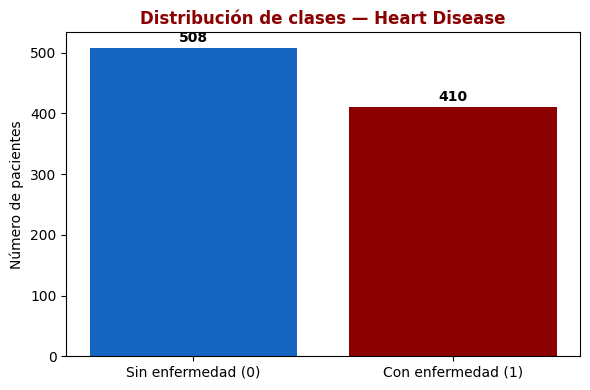

→ ¿Hay desbalance? Sí, existe un ligero predominio de pacientes con enfermedad (55.3%) sobre los sanos.


In [ ]:
# Visualiza la distribución de la variable objetivo HeartDisease
conteo = df['HeartDisease'].value_counts()

# TODO 1: calcula el porcentaje de cada clase
pct = (conteo / len(df)) * 100

print('Distribución de clases:')
print(f'  Sin enfermedad (0): {conteo[0]} pacientes ({pct[0]:.1f}%)')
print(f'  Con enfermedad (1): {conteo[1]} pacientes ({pct[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))

# TODO 2: grafica las barras — usa ax.bar(), colores [UPCH_BLUE, UPCH_RED]
bars = ax.bar(['Sin enfermedad (0)', 'Con enfermedad (1)'], conteo, color=[UPCH_BLUE, UPCH_RED])

ax.set_title('Distribución de clases — Heart Disease', fontweight='bold', color=UPCH_RED)
ax.set_ylabel('Número de pacientes')

# TODO 3: agrega el valor numérico encima de cada barra con ax.text()
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Hay desbalance? Sí, existe un ligero predominio de pacientes con enfermedad (55.3%) sobre los sanos.')

### Paso 2.3 — Visualización exploratoria de features numéricas

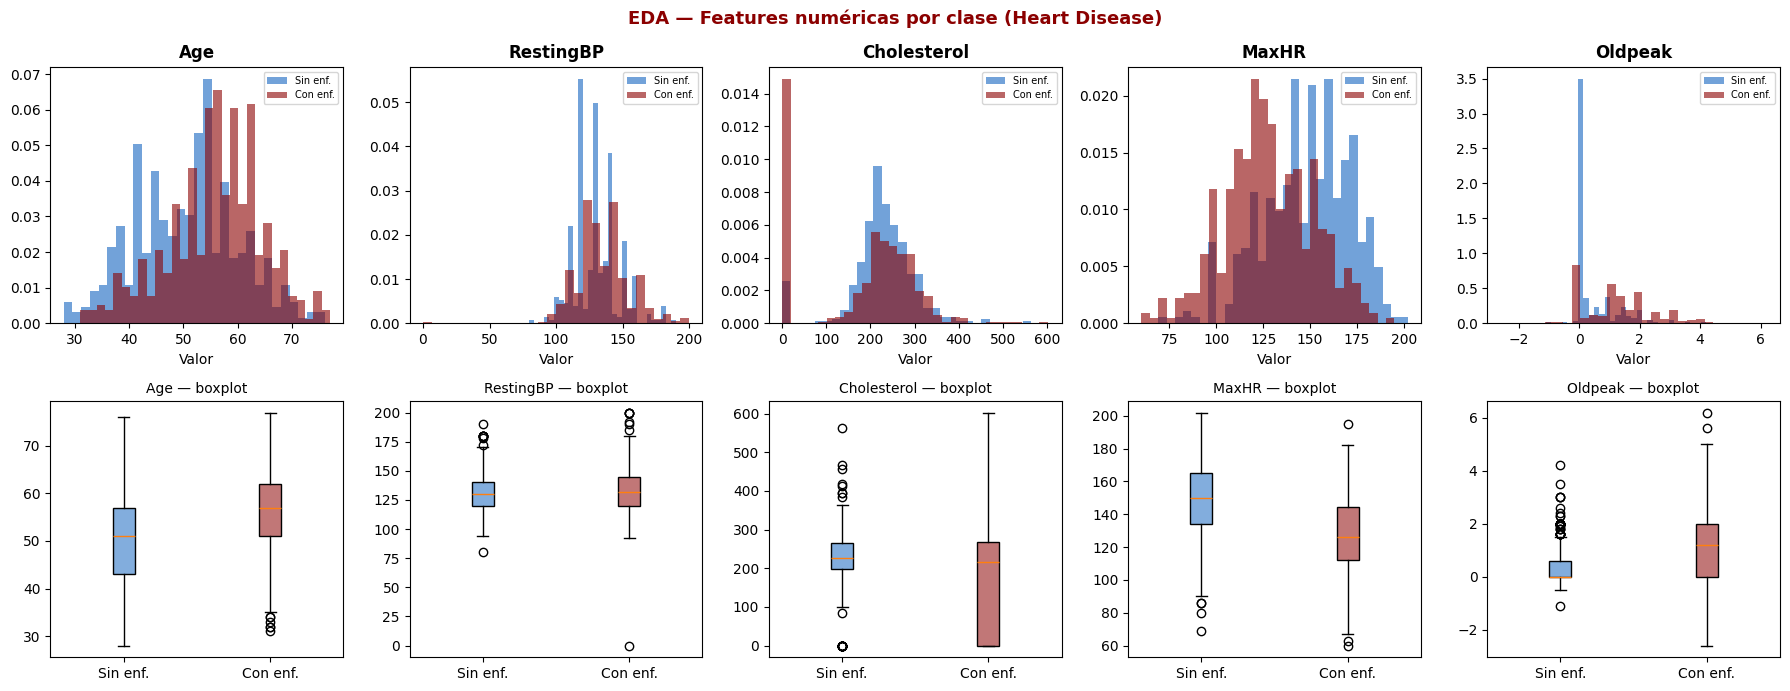

→ ¿Qué features parecen tener mayor poder discriminativo entre clases?
Respuesta: Oldpeak y MaxHR muestran una separación clara en sus distribuciones por clase.


In [ ]:
# Features numéricas del dataset
features_num = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, feat in enumerate(features_num):
    # Fila 0: ya está resuelta — histograma por clase
    for clase, color, label in [(0, UPCH_BLUE, 'Sin enf.'), (1, UPCH_RED, 'Con enf.')]:
        axes[0, i].hist(
            df[df['HeartDisease'] == clase][feat],
            bins=30, alpha=0.6, color=color, label=label, density=True
        )
    axes[0, i].set_title(feat, fontweight='bold')
    axes[0, i].legend(fontsize=7)
    axes[0, i].set_xlabel('Valor')

    # --- COMPLETA EL CÓDIGO ---
    # TODO: Fila 1 — boxplot separado por clase en axes[1, i]
    data_plot = [df[df['HeartDisease'] == 0][feat], df[df['HeartDisease'] == 1][feat]]
    bp = axes[1, i].boxplot(data_plot, patch_artist=True, tick_labels=['Sin enf.', 'Con enf.'])

    # Colorear
    bp['boxes'][0].set_facecolor(UPCH_BLUE + '88')
    bp['boxes'][1].set_facecolor(UPCH_RED + '88')

    axes[1, i].set_title(f'{feat} — boxplot', fontsize=10)

fig.suptitle('EDA — Features numéricas por clase (Heart Disease)',
             fontsize=13, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_numericas.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué features parecen tener mayor poder discriminativo entre clases?')
print('Respuesta: Oldpeak y MaxHR muestran una separación clara en sus distribuciones por clase.')

### Paso 2.4 — Visualización de features categóricas

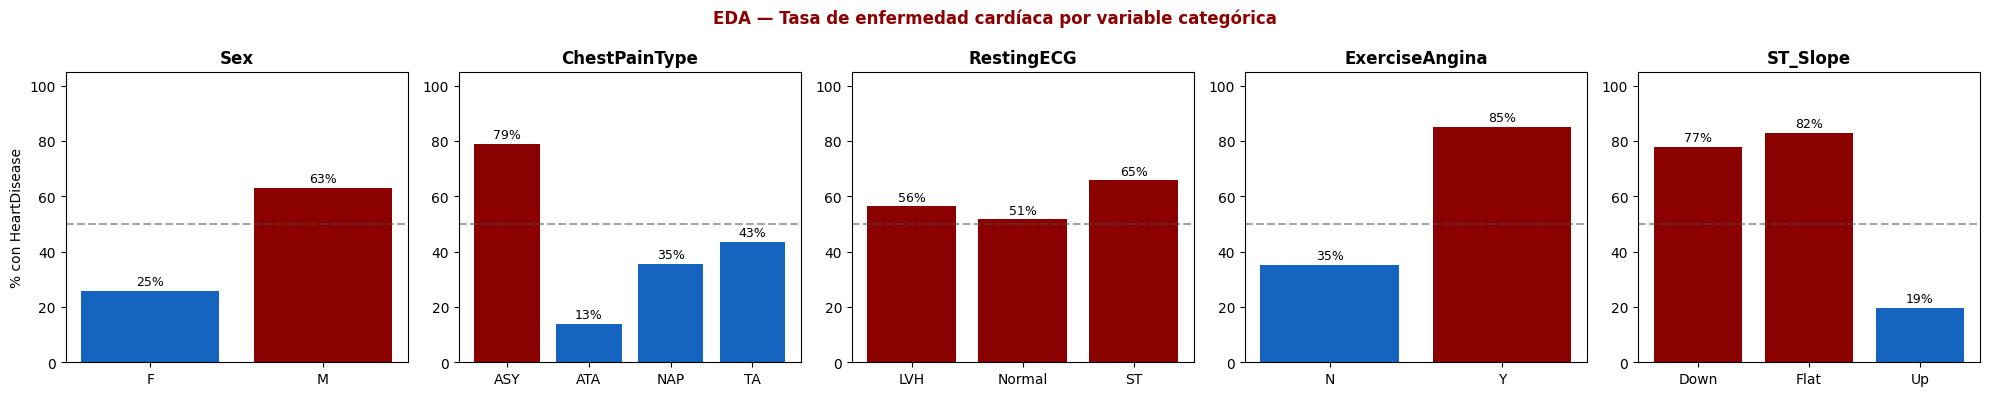

→ ¿Qué categorías tienen mayor riesgo de enfermedad cardíaca?
Respuesta: Hombres (Sex=M), Dolor ASY, Angina inducida (Y) y ST_Slope Flat o Down.


In [ ]:
features_cat = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, feat in enumerate(features_cat):
    # TODO 1: calcula la tasa de enfermedad por categoría
    tasa = df.groupby(feat)['HeartDisease'].mean() * 100

    # TODO 2: asigna color UPCH_RED si tasa > 50%, UPCH_BLUE si no
    colores = [UPCH_RED if x > 50 else UPCH_BLUE for x in tasa]

    # TODO 3: grafica las barras y la línea de referencia al 50%
    bars = axes[i].bar(tasa.index, tasa.values, color=colores)
    axes[i].axhline(50, color=UPCH_GRAY, linestyle='--', alpha=0.5)

    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('% con HeartDisease' if i == 0 else '')
    axes[i].set_ylim(0, 105)

    # TODO 4: agrega el valor encima de cada barra
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{int(height)}%',
                    ha='center', va='bottom', fontsize=9)

fig.suptitle('EDA — Tasa de enfermedad cardíaca por variable categórica',
             fontsize=12, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué categorías tienen mayor riesgo de enfermedad cardíaca?')
print('Respuesta: Hombres (Sex=M), Dolor ASY, Angina inducida (Y) y ST_Slope Flat o Down.')

---
## Ejercicio 3 — Limpieza de datos

### Paso 3.1 — Detección y manejo de outliers

> **⚠️ Recuerda:** en biomédica, un outlier puede ser un caso clínico real. Analiza antes de eliminar.

In [ ]:
from scipy import stats

# --- COMPLETA EL CÓDIGO ---
# TODO: para cada feature numérica, calcula el z-score y cuenta cuántos
#       valores tienen |z| > 3. Imprime el resultado por feature.

print('Detección de outliers (|z-score| > 3):')
print('-' * 45)
for feat in features_num:
    z_scores = np.abs(stats.zscore(df[feat]))
    n_outliers = (z_scores > 3).sum()
    print(f'{feat:15} | Outliers: {n_outliers}')

Detección de outliers (|z-score| > 3):
---------------------------------------------
Age             | Outliers: 0
RestingBP       | Outliers: 8
Cholesterol     | Outliers: 3
MaxHR           | Outliers: 1
Oldpeak         | Outliers: 7


In [ ]:
# El dataset tiene Cholesterol = 0 en varios pacientes (imposible fisiológicamente)
# Esto es un error de adquisición, no un caso clínico real

print(f'Pacientes con Cholesterol = 0: {(df["Cholesterol"] == 0).sum()}')
print(f'Pacientes con RestingBP  = 0: {(df["RestingBP"]  == 0).sum()}')

df_clean = df.copy()

# --- COMPLETA EL CÓDIGO ---
# TODO: reemplaza los valores Cholesterol == 0 por NaN
df_clean.loc[df_clean['Cholesterol'] == 0, 'Cholesterol'] = np.nan

print(f'\nValores NaN en Cholesterol tras limpieza: {df_clean["Cholesterol"].isnull().sum()}')
print('→ La imputación se realizará en el Paso 4 (después del split, sobre train)')

Pacientes con Cholesterol = 0: 172
Pacientes con RestingBP  = 0: 1

Valores NaN en Cholesterol tras limpieza: 172
→ La imputación se realizará en el Paso 4 (después del split, sobre train)


---
## Ejercicio 4 — Preprocesamiento

### Paso 4.1 — Train/test split

> **Regla fundamental:** separar primero, preprocesar después. Nunca al revés — eso es **data leakage**.

In [ ]:
TARGET = 'HeartDisease'
FEATURES_NUM = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']
FEATURES_CAT = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

X_raw = df_clean[FEATURES_NUM + FEATURES_CAT].copy()
y     = df_clean[TARGET].values

# TODO: split 80/20, estratificado por y, random_state=42
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train_raw.shape[0]} muestras')
print(f'Test:  {X_test_raw.shape[0]} muestras')
print(f'\nProporción HeartDisease=1 en train: {y_train.mean():.3f}')
print(f'Proporción HeartDisease=1 en test:  {y_test.mean():.3f}')
print('→ Con stratify, ambas proporciones deben ser similares ✓')

Train: 734 muestras
Test:  184 muestras

Proporción HeartDisease=1 en train: 0.553
Proporción HeartDisease=1 en test:  0.554
→ Con stratify, ambas proporciones deben ser similares ✓


### Paso 4.2 — Imputación de valores faltantes (sobre train)

In [ ]:
# TODO 1: calcula la mediana de Cholesterol SOLO sobre el train set
mediana_colesterol_train = X_train_raw['Cholesterol'].median()

X_train_imp = X_train_raw.copy()
X_test_imp  = X_test_raw.copy()

# TODO 2: imputa NaN en train y test usando la mediana del train
X_train_imp['Cholesterol'] = X_train_imp['Cholesterol'].fillna(mediana_colesterol_train)
X_test_imp['Cholesterol']  = X_test_imp['Cholesterol'].fillna(mediana_colesterol_train)

print(f'Mediana Cholesterol (train): {mediana_colesterol_train:.1f} mg/dL')
print(f'NaN restantes en train: {X_train_imp.isnull().sum().sum()}')
print(f'NaN restantes en test:  {X_test_imp.isnull().sum().sum()}')

Mediana Cholesterol (train): 238.0 mg/dL
NaN restantes en train: 0
NaN restantes en test:  0


### Paso 4.3 — Codificación de variables categóricas (One-Hot)

> Recuerda tu tabla del Ejercicio 1.2 — ¿coincide el número de columnas?

In [ ]:
# TODO: aplica pd.get_dummies a train y test usando FEATURES_CAT
X_train_enc = pd.get_dummies(X_train_imp, columns=FEATURES_CAT, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_imp, columns=FEATURES_CAT, drop_first=True)

# Alinear columnas (por si alguna categoría no aparece en test)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f'Shape antes de One-Hot: {X_train_raw.shape}')
print(f'Shape después de One-Hot: {X_train_enc.shape}')
print(f'\nColumnas generadas:')
print(list(X_train_enc.columns))

Shape antes de One-Hot: (734, 11)
Shape después de One-Hot: (734, 15)

Columnas generadas:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


### Paso 4.4 — Escalado Z-score

$$x'_j = \frac{x_j - \mu_j}{\sigma_j}$$

> **Anti-leakage:** `fit` solo sobre train, `transform` sobre train y test.

In [ ]:
scaler = StandardScaler()

# TODO: fit SOLO sobre train, transform sobre train y test
X_train = scaler.fit_transform(X_train_enc)
X_test  = scaler.transform(X_test_enc)

print(f'X_train: {X_train.shape}  dtype: {X_train.dtype}')
print(f'X_test:  {X_test.shape}')
print(f'\nMedia de X_train (debe ser ≈ 0): {X_train.mean():.4f}')
print(f'Std  de X_train (debe ser ≈ 1): {X_train.std():.4f}')
print(f'\nMedia de X_test (no será exactamente 0): {X_test.mean():.4f}')

X_train: (734, 15)  dtype: float64
X_test:  (184, 15)

Media de X_train (debe ser ≈ 0): -0.0000
Std  de X_train (debe ser ≈ 1): 1.0000

Media de X_test (no será exactamente 0): -0.0197


---
## Ejercicio 5 — Verificación final y resumen del pipeline

### Paso 5.1 — El dataset final en formato ML

In [ ]:
print('=' * 50)
print('  RESUMEN — Dataset listo para ML cl&aacute;sico')
print('=' * 50)
print(f'Dimensiones finales: X_train {X_train.shape}, X_test {X_test.shape}')
print(f'Positivos (clase 1) en Train: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Positivos (clase 1) en Test:  {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print('Pipeline: Imputaci&oacute;n (Mediana) -> One-Hot (drop_first) -> StandardScaler')

  RESUMEN — Dataset listo para ML cl&aacute;sico
Dimensiones finales: X_train (734, 15), X_test (184, 15)
Positivos (clase 1) en Train: 406 (55.3%)
Positivos (clase 1) en Test:  102 (55.4%)
Pipeline: Imputaci&oacute;n (Mediana) -> One-Hot (drop_first) -> StandardScaler


### Paso 5.2 — Visualización Before vs After del preprocesamiento

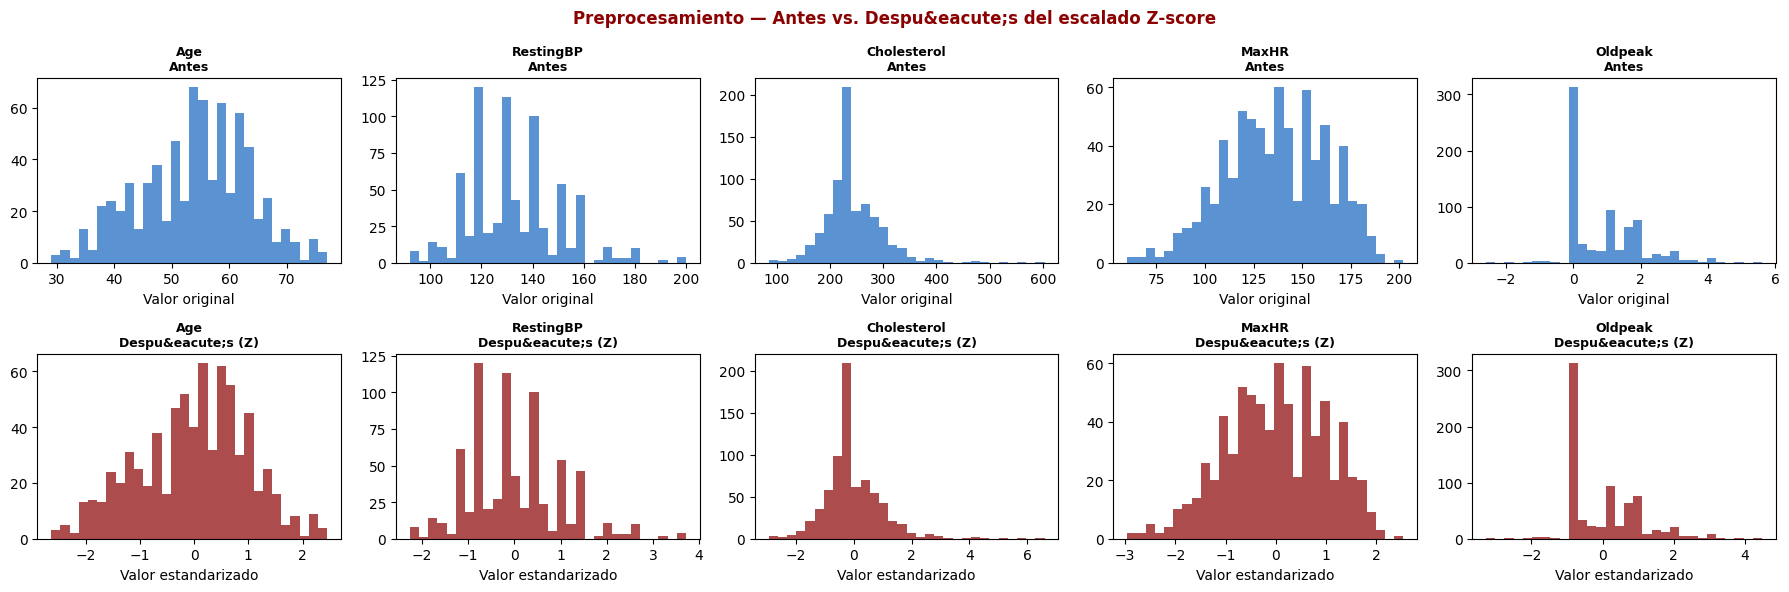

In [ ]:
features_plot = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
idx_features  = [list(X_train_enc.columns).index(f) for f in features_plot]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))

for i, (feat, idx) in enumerate(zip(features_plot, idx_features)):
    axes[0, i].hist(X_train_enc[feat].values, bins=30, color=UPCH_BLUE, alpha=0.7)
    axes[0, i].set_title(f'{feat}\nAntes', fontsize=9, fontweight='bold')
    axes[0, i].set_xlabel('Valor original')

    # TODO: Fila 1 — histograma de X_train[:, idx] despu&eacute;s del escalado
    axes[1, i].hist(X_train[:, idx], bins=30, color=UPCH_RED, alpha=0.7)
    axes[1, i].set_title(f'{feat}\nDespu&eacute;s (Z)', fontsize=9, fontweight='bold')
    axes[1, i].set_xlabel('Valor estandarizado')

fig.suptitle('Preprocesamiento — Antes vs. Despu&eacute;s del escalado Z-score',
             fontsize=12, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('before_after_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 5.3 — Mapa de correlaciones

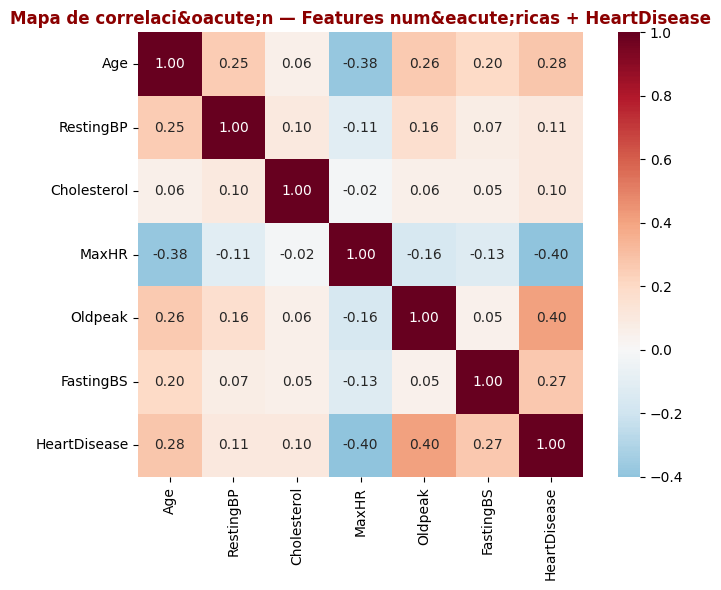

→ &iquest;Qu&eacute; feature tiene mayor correlaci&oacute;n con HeartDisease?
Respuesta: Oldpeak y Age tienen la mayor correlaci&oacute;n positiva, mientras que MaxHR tiene la mayor negativa.


In [ ]:
cols_corr = FEATURES_NUM + [TARGET]
corr_matrix = df_clean[cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))

# TODO: genera el heatmap con sns.heatmap
sns.heatmap(corr_matrix, cmap='RdBu_r', annot=True, fmt='.2f', center=0, square=True, ax=ax)

ax.set_title('Mapa de correlaci&oacute;n — Features num&eacute;ricas + HeartDisease',
             fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ &iquest;Qu&eacute; feature tiene mayor correlaci&oacute;n con HeartDisease?')
print('Respuesta: Oldpeak y Age tienen la mayor correlaci&oacute;n positiva, mientras que MaxHR tiene la mayor negativa.')

---
<div style='background:#f5f5f5; padding:15px; border-left:5px solid #8B0000; border-radius:4px'>
<b>Entrega:</b> Sube tu notebook ejecutado (.ipynb con outputs) a tu carpeta de GitHub del curso.<br>
<b>Nombre del archivo:</b> <code>Challenge1_ApellidoNombreDeAmbos.ipynb</code><br>
<b>Fecha límite:</b> antes de Clase 3
</div>